# Variable bottom bathymetry analysis for Appendix A

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as tick
import numpy as np
import xarray as xr
import xroms
import cartopy
from matplotlib.colors import BoundaryNorm
import cmocean.cm as cmo
import xarray as xr
from netCDF4 import Dataset
# from mpas_analysis.shared.io.utility import decode_strings
from glob import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
from matplotlib import ticker
from xhistogram.xarray import histogram
from matplotlib.ticker import FuncFormatter
import mosaic
from matplotlib.colors import SymLogNorm
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import SymLogNorm


import warnings 
warnings.filterwarnings("ignore") #turns off annoying warnings

In [2]:
# ROMS 
his_file = 'bichan_roms/runs/1km/roms_his.nc'
ds = xroms.open_mfnetcdf(glob(his_file))
dsr, grid = xroms.roms_dataset(ds,include_cell_volume=True)

# MPAS-O 
rootdir = 'bichan_mpaso/runs/1km/sloping_bottom/'

# Load datasets
dso = xr.open_dataset(rootdir + 'output_1000m_30_layers.nc', chunks={"Time": 100})#.isel(Time=slice(1, None))
dsi = xr.open_dataset(rootdir + 'channel_1000m_30_layers_init.nc')

In [3]:
### Preprocess ROMS and MPAS-O 
def to_rho(var):
    if var.dims[-1] != 'xi_rho':
        var = grid.interp(var, 'X', to='center', boundary='extend')
    if var.dims[-2] != 'eta_rho':
        var = grid.interp(var, 'Y', to='center', boundary='extend')
    return var

def velgrad(ds,grid):
    '''
    Calculates flow invariants vorticity, divergence, strain
    '''
    us = ds.u 
    vs = ds.v

    dudx = grid.derivative(us, 'X', boundary='extend')
    dvdy = grid.derivative(vs, 'Y', boundary='extend')
    dudy = to_rho(grid.derivative(us, 'Y', boundary='extend'))
    dvdx = to_rho(grid.derivative(vs, 'X', boundary='extend'))
    # Vorticity:  v_x - u_y
    rv = (dvdx - dudy)/ds.f
    rv.name = 'Normalized vorticity'

    # Divergence: u_x + v_y
    delta = (dudx + dvdy)/ds.f
    delta.name = 'Normalized divergence'

    # Major axis of deformation
    alpha = ( np.sqrt( (dudx-dvdy)**2 + (dvdx+dudy)**2 ) )/ds.f
    alpha.name = 'Normalized strain'
    
    return rv,delta,alpha

rv,delta,alpha = velgrad(dsr,grid)

### Compute volume integrals of KE

In [4]:
ke = dso.kineticEnergyCell
dV = dsi.areaCell*dso.layerThickness 
V = dV.sum(['nCells','nVertLevels'])

kem = ((1/V)*((ke*dV).sum(['nCells','nVertLevels']))).compute()

In [5]:
speed = xroms.speed(dsr.u, dsr.v, grid)
KE = xroms.KE(dsr.rho0, speed)
dsr['ke'] = KE

Vr = dsr.dV.sum(['s_rho','eta_rho','xi_rho'])
ker = ((1/Vr)*((dsr.ke*dsr.dV).sum(['s_rho','eta_rho','xi_rho']))).compute()

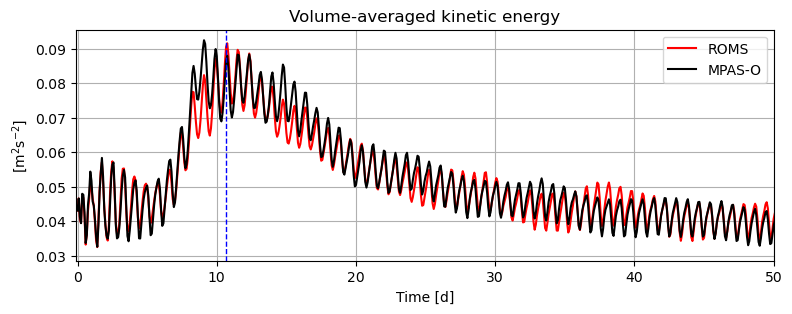

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

time = np.arange(0, 60*24 + 2, 2)/24  # time in days

plt.plot(time, ker/dsr.rho0, label='ROMS', c = 'r')
plt.plot(time, kem, label='MPAS-O', c = 'k')

# Vertical line at t = 200 hours
ax.axvline(x=128/12, color='b', linestyle='--', linewidth=1)

plt.grid()
plt.ylabel(r'[m$^2$s$^{-2}$]')
plt.xlim(-0.1, 50)
plt.title('Volume-averaged kinetic energy')
plt.xlabel('Time [d]')
plt.legend()
plt.savefig(r'ke_sloping_bottom.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
kem.to_netcdf('sloping_bottom/ke_mpas_1km_sloping_bottom.nc')
ker.to_netcdf('sloping_bottom/ke_roms_1km_sloping_bottom.nc')

### Make cross sections of tracers 

In [10]:
# --- Time index ---
tidx = 128

# -----------------------
# --- ROMS Data ---
# -----------------------
u_slice    = dsr.u[tidx, :, :, :].mean('xi_u').values       # (z_rho, y_u)
z_u_slice  = dsr.z_rho_u[tidx, :, :, :].mean('xi_u').values # (z_rho, y_u)
y_u        = dsr.y_u[:, 0].values                           # across-shore

# ROMS bottom layer (s_w = -1)
bottom_ROMS_line = dsr.z_w[tidx, 0, :, 0].values  # bottom depth along y_u

# -----------------------
# --- MPAS-O Data ---
# -----------------------
velocityZonal = dso.velocityZonal[tidx, :, :]      # (nCells, nVertLevels)
layerThickness = dso.layerThickness[tidx, :, :]   # (nCells, nVertLevels)
nCells, nVertLevels = layerThickness.shape
y_cell = dsi.yCell.values

# Compute vertical coordinates
zTop = np.zeros_like(layerThickness)
zBottom = np.zeros_like(layerThickness)
zBottom[:, 0] = -layerThickness[:, 0]
for k in range(1, nVertLevels):
    zTop[:, k] = zBottom[:, k-1]
    zBottom[:, k] = zTop[:, k] - layerThickness[:, k]
zMid = 0.5 * (zTop + zBottom)

# Bin cells acrossshore
n_y_bins = 150
y_bins = np.linspace(y_cell.min(), y_cell.max(), n_y_bins + 1)
y_centers = 0.5 * (y_bins[:-1] + y_bins[1:])
bin_idx = np.digitize(y_cell, y_bins) - 1
bin_idx[bin_idx == n_y_bins] = n_y_bins - 1

# --- Alongshore mean of velocity ---
velocityZonal_cross = np.zeros((n_y_bins, nVertLevels))
for k in range(nVertLevels):
    sum_vel = np.bincount(bin_idx, weights=velocityZonal[:, k], minlength=n_y_bins)
    count = np.bincount(bin_idx, minlength=n_y_bins)
    velocityZonal_cross[:, k] = sum_vel / np.maximum(count, 1)

# --- Alongshore mean of layer interfaces ---
zMid_cross = np.zeros((n_y_bins, nVertLevels))
for k in range(nVertLevels):
    sum_z = np.bincount(bin_idx, weights=zMid[:, k], minlength=n_y_bins)
    count = np.bincount(bin_idx, minlength=n_y_bins)
    zMid_cross[:, k] = sum_z / np.maximum(count, 1)

# --- Alongshore mean of bottom layer ---
bottom_MPAS_cross = np.zeros(n_y_bins)
sum_bottom = np.bincount(bin_idx, weights=zBottom[:, -1], minlength=n_y_bins)
count = np.bincount(bin_idx, minlength=n_y_bins)
bottom_MPAS_cross[:] = sum_bottom / np.maximum(count, 1)

# --- Shift MPAS y to start at 0 for alignment with ROMS ---
y_centers_shifted = y_centers - y_centers.min()

# Convert from meters to km
y_u_km = y_u / 1000.0
y_centers_shifted_km = y_centers_shifted / 1000.0

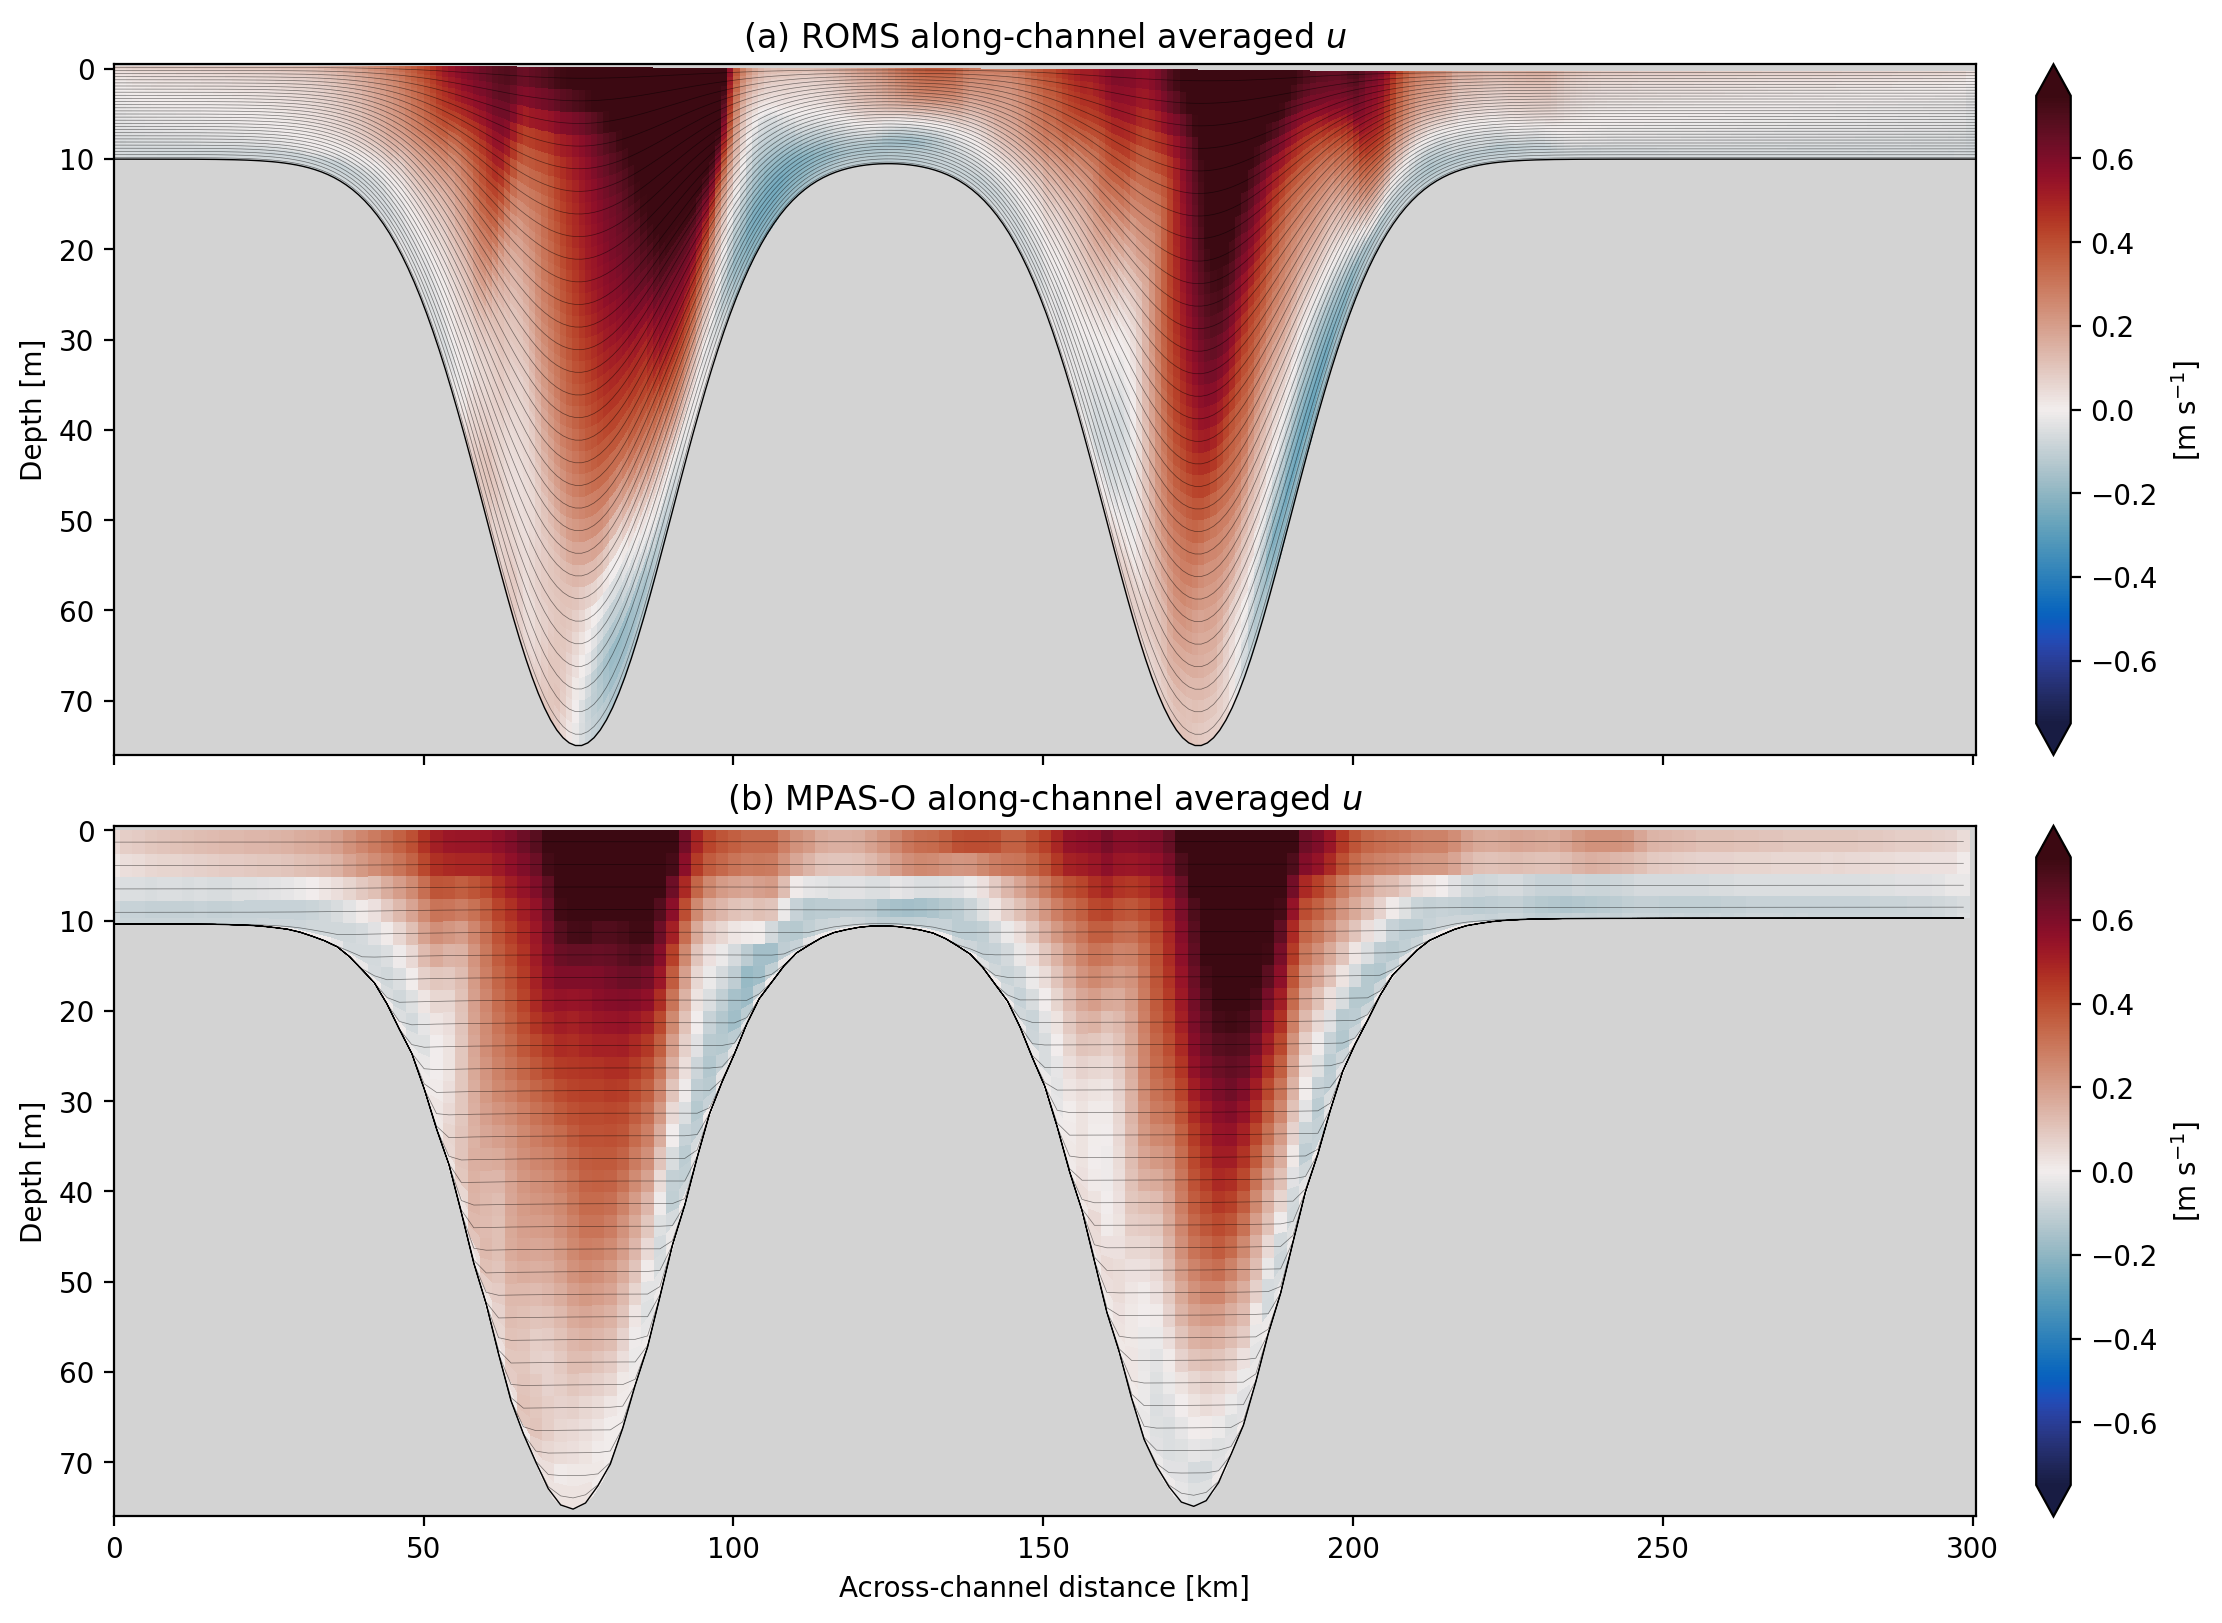

In [11]:
# -----------------------
# --- Plot ROMS vs MPAS-O (km) ---
# -----------------------
fig, ax = plt.subplots(2, 1, figsize=(11, 8), dpi=200, constrained_layout=True, sharex=True, sharey=True)

# --- ROMS ---
pcm0 = ax[0].pcolormesh(y_u_km, -z_u_slice, u_slice,
                        shading='auto', cmap=cmo.balance, vmin=-0.75, vmax=0.75)
# Overlay s_rho layers
for k in range(z_u_slice.shape[0]):
    ax[0].plot(y_u_km, -z_u_slice[k, :], color='k', linewidth=0.25, alpha=0.5)
# Overlay bottom layer
ax[0].plot(y_u_km, -bottom_ROMS_line, color='k', linewidth=0.5)
ax[0].set_title("(a) ROMS along-channel averaged $u$")
ax[0].set_xlabel("")
ax[0].set_ylabel("Depth [m]")
ax[0].invert_yaxis()
ax[0].set_facecolor('lightgray')
ax[0].set_ylim(76, -0.5)
ax[0].set_xlim(0, 300.5)
fig.colorbar(pcm0, ax=ax[0], label=r'[m s$^{-1}$]', pad=0.02, extend = 'both')

# --- MPAS-O ---
pcm1 = ax[1].pcolormesh(y_centers_shifted_km, -zMid_cross.T, velocityZonal_cross.T,
                        shading='auto', cmap=cmo.balance, vmin=-0.75, vmax=0.75)
fig.colorbar(pcm1, ax=ax[1], label=r'[m s$^{-1}$]', pad=0.02, extend = 'both')
# Overlay MPAS-O layer interfaces
for k in range(nVertLevels):
    ax[1].plot(y_centers_shifted_km, -zMid_cross[:, k], color='k', linewidth=0.25, alpha=0.5)
# Overlay MPAS-O bottom
ax[1].plot(y_centers_shifted_km, -bottom_MPAS_cross, color='k', linewidth=0.5)
ax[1].set_title("(b) MPAS-O along-channel averaged $u$")
ax[1].set_xlabel("Across-channel distance [km]")
ax[1].set_ylabel("Depth [m]")
ax[1].set_facecolor('lightgray')
ax[1].set_ylim(76, -0.5)
ax[1].set_xlim(0, 300.5)

plt.savefig(r'sloping_bottom_cross_sections.png', dpi=300, bbox_inches='tight')
plt.show()
